In [14]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# BGVAR Sampler — Diagnostic Notebook

This notebook produces convergence diagnostics, mixing analysis, and posterior summaries for the post-burn-in samples written by `main.py`.

### Setup

In [15]:

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent           
SAMPLES_DIR  = PROJECT_ROOT / "outputs" 

LAG_LABELS = {0: "lag 1", 1: "lag 7"}

STATES = ["AT", "BE", "BG", "CH", "CZ", "DE", "DK", "EE", "ES","FI","FR", "GR",
          "HR", "HU", "IE", "IT", "LT", "LV", "ME", "NL", "NO", "PL", "PT",
          "RO", "RS", "SE", "SI", "SK"]
VARS_PER_STATE =  ['Price']
VAR_NAMES = [f"{s}_{v}" for s in STATES for v in VARS_PER_STATE]


def status_ess(ess_frac: float) -> str:
    """ESS efficiency thresholds — returns a status emoji."""
    if ess_frac < 0.01:
        return "🔴"
    if ess_frac < 0.05:
        return "🟡"
    return "🟢"

def status_geweke(z: float) -> str:
    """Geweke z-score thresholds."""
    az = abs(z)
    if az > 3:
        return "🔴"
    if az > 2:
        return "🟡"
    return "🟢"

def status_rhat(r: float) -> str:
    """Split R-hat thresholds."""
    if r > 1.05:
        return "🔴"
    if r > 1.01:
        return "🟡"
    return "🟢"


### Core diagnostics : ESS, Geweke, split R-hat, ACF
These are the building blocks reused throughout the notebook.

In [16]:
def autocovariance(x: np.ndarray, max_lag: int | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    n = x.size
    if max_lag is None:
        max_lag = n - 1
    xc = x - x.mean()
    nfft = 1 << (2 * n - 1).bit_length()
    f = np.fft.fft(xc, n=nfft)
    acov = np.fft.ifft(f * np.conjugate(f)).real[:max_lag + 1] / n
    return acov


def ess_geyer(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    n = x.size
    if n < 4 or np.var(x) == 0.0:
        return float(n)

    acov = autocovariance(x)
    rho = acov / acov[0]

    max_pairs = (n - 2) // 2
    pair_sums = rho[1:1 + 2 * max_pairs:2] + rho[2:2 + 2 * max_pairs:2]

    pos = np.where(pair_sums <= 0)[0]
    cutoff = pos[0] if pos.size else max_pairs
    pair_sums = pair_sums[:cutoff]

    for i in range(1, pair_sums.size):
        if pair_sums[i] > pair_sums[i - 1]:
            pair_sums[i] = pair_sums[i - 1]

    tau = max(1.0 + 2.0 * pair_sums.sum(), 1.0)
    return float(n / tau)


def geweke_z(x: np.ndarray, first: float = 0.1, last: float = 0.5) -> float:
    n = x.size
    n_a = max(int(n * first), 2)
    n_b = max(int(n * last), 2)
    a, b = x[:n_a], x[-n_b:]

    var_a = a.var(ddof=1) * n_a / max(ess_geyer(a), 1.0)
    var_b = b.var(ddof=1) * n_b / max(ess_geyer(b), 1.0)
    se = np.sqrt(var_a / n_a + var_b / n_b)
    return 0.0 if se == 0 else float((a.mean() - b.mean()) / se)


def split_rhat(x: np.ndarray) -> float:
    n = x.size
    half = n // 2
    if half < 4:
        return np.nan
    chains = np.stack([x[:half], x[half:2 * half]])
    m, n_per = chains.shape
    chain_means = chains.mean(axis=1)
    chain_vars = chains.var(axis=1, ddof=1)
    B = n_per * chain_means.var(ddof=1)
    W = chain_vars.mean()
    if W == 0:
        return 1.0
    var_hat = (n_per - 1) / n_per * W + B / n_per
    return float(np.sqrt(var_hat / W))


def summarize_scalar(x: np.ndarray) -> dict:
    ess = ess_geyer(x)
    return {
        "mean":   float(x.mean()),
        "median": float(np.median(x)),
        "std":    float(x.std(ddof=1)),
        "q05":    float(np.quantile(x, 0.05)),
        "q95":    float(np.quantile(x, 0.95)),
        "ess":    ess,
        "ess_frac": ess / x.size,
        "geweke": geweke_z(x),
        "rhat":   split_rhat(x),
        "n":      x.size,
    }


def kl_bernoulli_to_uniform(p: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    p = np.clip(p, eps, 1 - eps)
    return p * np.log(2 * p) + (1 - p) * np.log(2 * (1 - p))

# Data import

In [17]:
def load_samples(samples_dir: Path) -> dict[str, np.ndarray]:
    samples = {}
    for f in sorted(samples_dir.glob("*_samples.npy")):
        key = f.stem.replace("_samples", "")
        samples[key] = np.load(f)
    # Physical-network mask (constant across the chain)
    mask_path = samples_dir / "G0_expanded.npy"
    if mask_path.exists():
        samples["G0_expanded"] = np.load(mask_path)
    return samples


def companion_spectral_radius(Phi_draw: np.ndarray) -> float:
    """
    Spectral radius of the VAR companion matrix for one posterior draw.
    Phi_draw has shape (ny, ny, n_lags).
    """
    ny, _, p = Phi_draw.shape
    A = np.zeros((ny * p, ny * p))
    # First block row: [Phi_1, Phi_2, ..., Phi_p]
    for s in range(p):
        A[:ny, s * ny:(s + 1) * ny] = Phi_draw[:, :, s]
    # Identity sub-diagonal
    for s in range(p - 1):
        A[(s + 1) * ny:(s + 2) * ny, s * ny:(s + 1) * ny] = np.eye(ny)
    return float(np.max(np.abs(np.linalg.eigvals(A))))


def derived_scalars(samples: dict, compute_spectral: bool = False) -> dict[str, np.ndarray]:
    """
    Build the 1D arrays of length N_KEEP used by the dashboard.
    Spectral radius is expensive (O(N) eigendecompositions of a (ny*p)^2 matrix);
    set compute_spectral=False to skip it during development.
    """
    out = {}

    if "G0" in samples:
        out["G0_active_edges"] = samples["G0"].sum(axis=(0, 1)).astype(np.float64)

    if "G_Phi" in samples:
        # Total active arcs and per-lag breakdown
        out["G_Phi_active_arcs"] = samples["G_Phi"].sum(axis=(0, 1, 2)).astype(np.float64)
        for s, label in LAG_LABELS.items():
            if s < samples["G_Phi"].shape[2]:
                out[f"G_Phi_{label.replace(' ', '')}"] = (
                    samples["G_Phi"][:, :, s, :].sum(axis=(0, 1)).astype(np.float64)
                )
    
    if "G_Gamma" in samples:
        # Total active arcs and per-lag breakdown
        out["G_Gamma_active_arcs"] = samples["G_Gamma"].sum(axis=(0, 1, 2)).astype(np.float64)
        for s, label in LAG_LABELS.items():
            if s < samples["G_Gamma"].shape[2]:
                out[f"G_Gamma_{label.replace(' ', '')}"] = (
                    samples["G_Gamma"][:, :, s, :].sum(axis=(0, 1)).astype(np.float64)
                )

    if "logdet_Sigma" in samples:
        out["logdet_Sigma_u"] = samples["logdet_Sigma"].astype(np.float64)

    if "Sigma_u" in samples:
        Sig = samples["Sigma_u"]
        ny = Sig.shape[0]
        idx = np.arange(ny)
        out["tr_Sigma_u"] = Sig[idx, idx, :].sum(axis=0).astype(np.float64)

    if "Phi" in samples:
        Phi = samples["Phi"]
        out["Phi_frobenius"] = np.sqrt((Phi ** 2).sum(axis=(0, 1, 2))).astype(np.float64)
        out["Phi_max_abs"] = np.max(np.abs(Phi), axis=(0, 1, 2)).astype(np.float64)
        if compute_spectral:
            print("  computing Phi spectral radii (this may take a while)...")
            N = Phi.shape[-1]
            radii = np.empty(N)
            for k in range(N):
                radii[k] = companion_spectral_radius(Phi[:, :, :, k])
                if (k + 1) % 1000 == 0:
                    print(f"    {k + 1}/{N}")
            out["spectral_radius_Phi"] = radii
    
    if "Gamma" in samples:
        Gamma = samples["Gamma"]
        n_wind = 28
    
        # Split dei coefficienti
        gamma_wind = Gamma[:, :n_wind, :, :]
        gamma_solar = Gamma[:, n_wind:, :, :]
    
        # 1. Magnitudo  per gruppo
        out["Gamma_wind_frob"] = np.sqrt((gamma_wind ** 2).sum(axis=(0, 1, 2))).astype(np.float64)
        out["Gamma_solar_frob"] = np.sqrt((gamma_solar ** 2).sum(axis=(0, 1, 2))).astype(np.float64)
    
        # 2. Sparsità 
        if "G_Gamma" in samples:
            G = samples["G_Gamma"]
            G_wind = G[:, :n_wind, :, :]
            G_solar = G[:, n_wind:, :, :]
        
            out["G_Gamma_wind_active"] = G_wind.sum(axis=(0, 1, 2)).astype(np.float64)
            out["G_Gamma_solar_active"] = G_solar.sum(axis=(0, 1, 2)).astype(np.float64)

        # 3. Valore assoluto massimo per gruppo
        out["Gamma_wind_max"] = np.max(np.abs(gamma_wind), axis=(0, 1, 2)).astype(np.float64)
        out["Gamma_solar_max"] = np.max(np.abs(gamma_solar), axis=(0, 1, 2)).astype(np.float64)

    for key in ("mu_h", "phi_h", "sigma_h2"):
        if key in samples:
            out[key] = samples[key].astype(np.float64)

    if "h" in samples:
        out["mean_h_t"] = samples["h"].mean(axis=0).astype(np.float64)
    if "lambda_t" in samples:
        out["mean_lambda_t"] = samples["lambda_t"].mean(axis=0).astype(np.float64)
        out["max_lambda_t"]  = samples["lambda_t"].max(axis=0).astype(np.float64)

    return out


print("Loading current run...")
samples = load_samples(SAMPLES_DIR)
print(f"  loaded {len(samples)} arrays")
for k, v in samples.items():
    print(f"  {k:<20} shape={v.shape}  dtype={v.dtype}")

print("\nBuilding derived scalars (set compute_spectral=False to skip)...")
scalars = derived_scalars(samples, compute_spectral=True)
print(f"  built {len(scalars)} scalar quantities")

N_KEEP = next(iter(scalars.values())).size
print(f"\nN_KEEP = {N_KEEP}")

Loading current run...
  loaded 15 arrays
  G0                   shape=(28, 28, 10000)  dtype=uint8
  G_Gamma              shape=(28, 53, 2, 10000)  dtype=uint8
  G_Phi                shape=(28, 28, 2, 10000)  dtype=uint8
  gamma_norm           shape=(10000,)  dtype=float64
  Gamma                shape=(28, 53, 2, 10000)  dtype=float64
  h                    shape=(358, 10000)  dtype=float32
  lambda_t             shape=(358, 10000)  dtype=float32
  logdet_Sigma         shape=(10000,)  dtype=float32
  mu_h                 shape=(10000,)  dtype=float32
  phi_h                shape=(10000,)  dtype=float32
  phi_norm             shape=(10000,)  dtype=float64
  Phi                  shape=(28, 28, 2, 10000)  dtype=float32
  sigma_h2             shape=(10000,)  dtype=float32
  Sigma_u              shape=(28, 28, 10000)  dtype=float32
  G0_expanded          shape=(28, 28)  dtype=uint8

Building derived scalars (set compute_spectral=False to skip)...
  computing Phi spectral radii (this may ta

Note:
- 'spectral radius' prende il massimo eigenvalue di $\Phi$ con i lag impilati, misura quanto rapidamente uno shock si attenua nel tempo
- 'trace Sigma' è la somma di "quanto rumore residuo" rimane su ciascuna equazione del VAR

## Global Health Check
If everything is green, the chain is healthy and you can move to interpretation. 
If anything is yellow or red, drill down into the relevant block-specific cell.

In [18]:
def build_dashboard(scalars: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for name, x in scalars.items():
        s = summarize_scalar(x)
        rows.append({
            "Quantity":   name,
            "Median":     f"{s['median']:.4f}",
            "Mean":       f"{s['mean']:.4f}",
            "90% CI":     f"[{s['q05']:.3f}, {s['q95']:.3f}]",
            "ESS":        f"{s['ess']:.0f}",
            "ESS/N (%)":  f"{100 * s['ess_frac']:.1f}",
            "Geweke z":   f"{s['geweke']:+.2f}",
            "R̂":          f"{s['rhat']:.3f}",
            "Status":     f"{status_ess(s['ess_frac'])} {status_geweke(s['geweke'])} {status_rhat(s['rhat'])}",
        })
    return pd.DataFrame(rows).set_index("Quantity")

dashboard = build_dashboard(scalars)
dashboard

,Median,Mean,90% CI,ESS,ESS/N (%),Geweke z,R̂,Status
Quantity,,,,,,,,
G0_active_edges,39.0000,39.3430,"[37.000, 41.000]",1025,10.3,+0.44,1.000,🟢 🟢 🟢
G_Phi_active_arcs,839.0000,839.4559,"[810.000, 872.000]",41,0.4,-3.18,1.005,🔴 🔴 🟢
G_Phi_lag1,390.0000,391.4270,"[370.000, 414.000]",34,0.3,-2.86,1.008,🔴 🟡 🟢
G_Phi_lag7,448.0000,448.0289,"[429.000, 465.000]",57,0.6,-1.38,1.000,🔴 🟢 🟢
G_Gamma_active_arcs,1600.0000,1600.0935,"[1560.000, 1640.000]",49,0.5,+1.24,1.042,🔴 🟢 🟡
G_Gamma_lag1,818.0000,817.6041,"[790.000, 844.000]",37,0.4,+2.49,1.071,🔴 🟡 🔴
G_Gamma_lag7,782.0000,782.4894,"[757.000, 807.000]",78,0.8,-0.70,1.002,🔴 🟢 🟢
logdet_Sigma_u,351.4204,351.3195,"[347.240, 355.081]",891,8.9,+2.02,1.004,🟢 🟡 🟢
tr_Sigma_u,35497818.0000,35572737.0410,"[30175820.000, 41187115.400]",1089,10.9,+2.39,1.003,🟢 🟡 🟢


## Convergence health check: running means

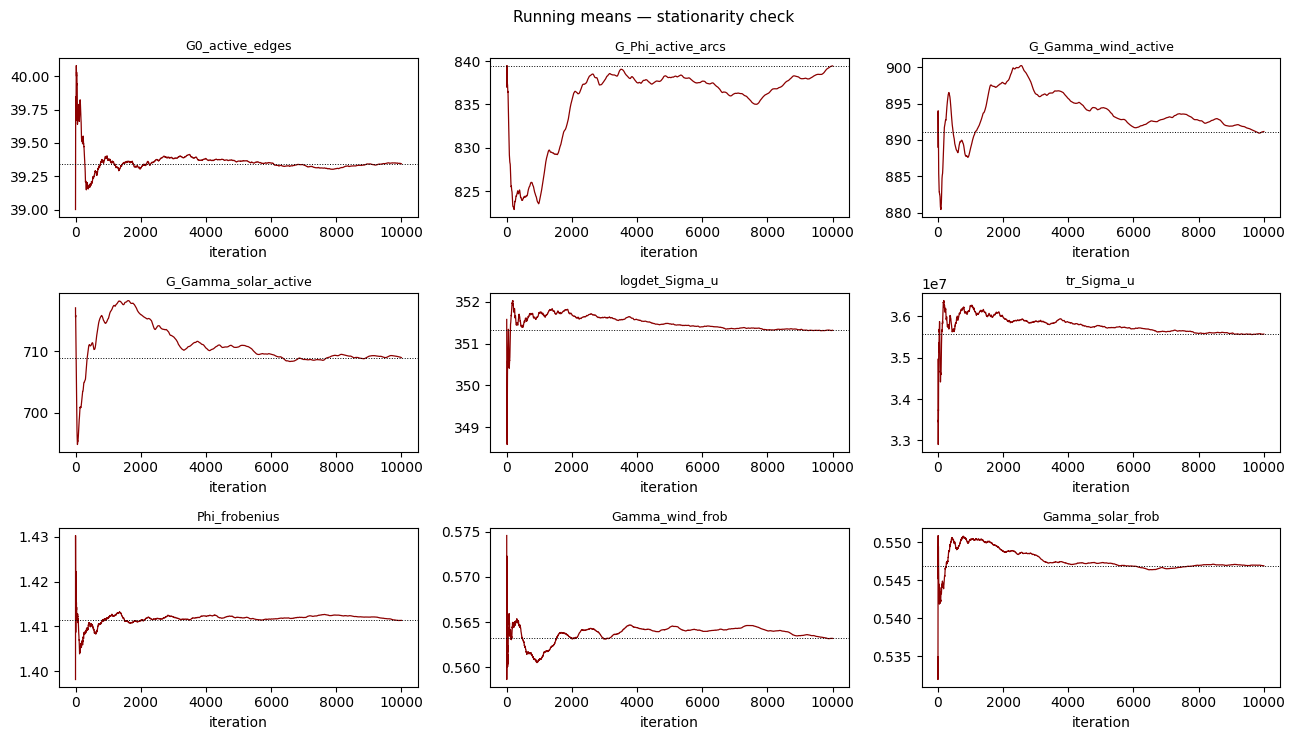

In [19]:
def plot_running_means(scalars: dict[str, np.ndarray],
                       keys: list[str],
                       title: str,
                       out_path: Path | None = None) -> None:
    n_q = len(keys)
    n_cols = 3
    n_rows = int(np.ceil(n_q / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.5 * n_rows),
                             squeeze=False)

    for k, key in enumerate(keys):
        ax = axes[k // n_cols, k % n_cols]
        x = scalars[key]
        running = np.cumsum(x) / np.arange(1, x.size + 1)
        ax.plot(running, lw=0.9, color="darkred")
        ax.axhline(x.mean(), color="black", ls=":", lw=0.7)
        ax.set_title(key, fontsize=9)
        ax.set_xlabel("iteration")

    # Hide unused subplots
    for k in range(n_q, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].axis("off")

    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=120)
    plt.show()


# Pick the most important quantities for the health check
DASHBOARD_KEYS = [
    "G0_active_edges", "G_Phi_active_arcs",
     "G_Gamma_wind_active",  "G_Gamma_solar_active",
    "logdet_Sigma_u", "tr_Sigma_u",
    "Phi_frobenius", "spectral_radius",
    "Gamma_wind_frob", "Gamma_solar_frob",
   
]
DASHBOARD_KEYS = [k for k in DASHBOARD_KEYS if k in scalars]

plot_running_means(scalars, DASHBOARD_KEYS,
                   "Running means — stationarity check")

## Block diagnostics of $G_0$ (contemporaneous graph)

G_0 — non-degenerate arcs: 76
      median ESS:          1772
      arcs below ESS=100:  0 (0.0%)
      degenerate arcs:     680


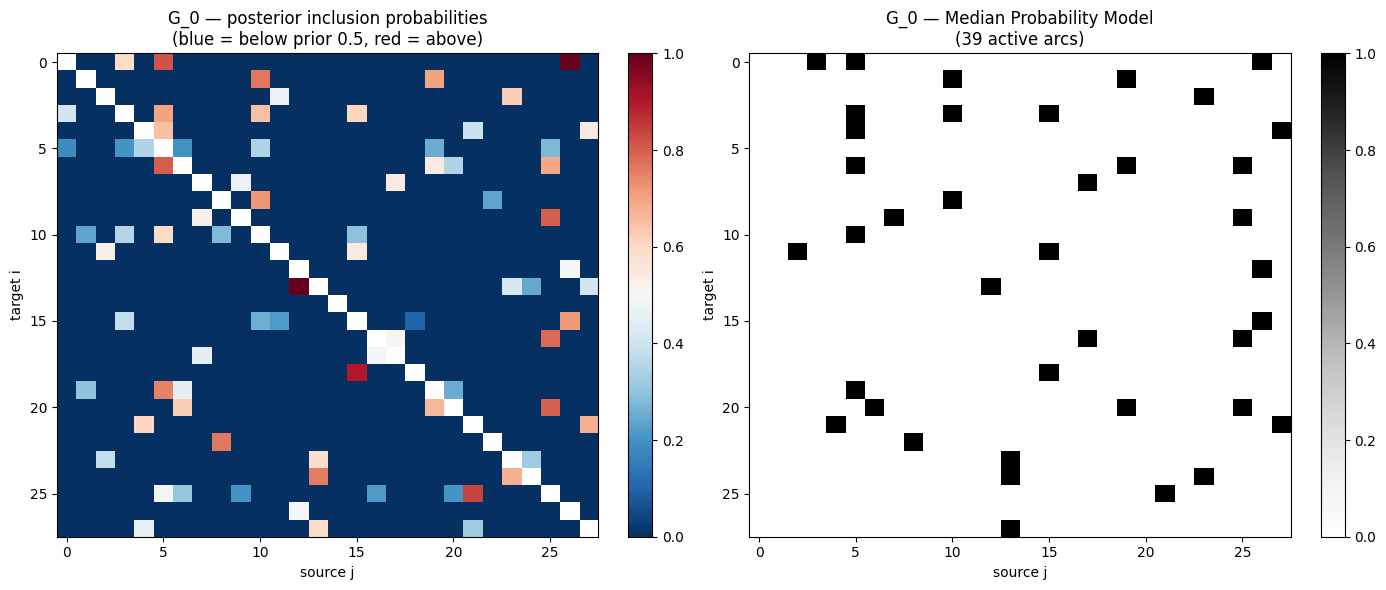

      mean KL(post || prior 0.5) over arcs: 0.6320
        (≈ 0 means uninformative; > 0.05 means strong departure)


In [20]:
if "G0" in samples:
    G0 = samples["G0"]                  # (ny, ny, N)
    ny, _, N = G0.shape

    # Per-arc inclusion probabilities
    edge_prob_G0 = G0.mean(axis=2)      # (ny, ny)
    np.fill_diagonal(edge_prob_G0, np.nan)

    # Per-arc ESS, masking the diagonal
    ess_per_arc = np.empty((ny, ny))
    for i in range(ny):
        for j in range(ny):
            if i == j:
                ess_per_arc[i, j] = np.nan
            else:
                ess_per_arc[i, j] = ess_geyer(G0[i, j, :].astype(np.float64))

    # Identify degenerate arcs (always 0 or always 1)
    arc_var = G0.var(axis=2)
    np.fill_diagonal(arc_var, np.nan)
    degenerate_mask = (arc_var == 0)
    n_degenerate = int(np.nansum(degenerate_mask))

    # ESS summary on non-degenerate arcs only
    ess_live = ess_per_arc[~degenerate_mask & ~np.isnan(ess_per_arc)]
    print(f"G_0 — non-degenerate arcs: {ess_live.size}")
    print(f"      median ESS:          {np.median(ess_live):.0f}")
    print(f"      arcs below ESS=100:  {(ess_live < 100).sum()} "
          f"({100*(ess_live < 100).mean():.1f}%)")
    print(f"      degenerate arcs:     {n_degenerate}")

    # --- Heatmap of inclusion probabilities, divergent colormap centered on 0.5
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im0 = axes[0].imshow(edge_prob_G0, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    axes[0].set_title(f"G_0 — posterior inclusion probabilities\n"
                      f"(blue = below prior 0.5, red = above)")
    axes[0].set_xlabel("source j")
    axes[0].set_ylabel("target i")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    # Median Probability Model (MPM)
    G0_mpm = (edge_prob_G0 > 0.5).astype(np.float32)
    n_mpm = int(np.nansum(G0_mpm))
    im1 = axes[1].imshow(G0_mpm, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    axes[1].set_title(f"G_0 — Median Probability Model\n({n_mpm} active arcs)")
    axes[1].set_xlabel("source j")
    axes[1].set_ylabel("target i")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    fig.tight_layout()
    plt.show()

    # --- KL divergence: how far is the posterior from the prior?
    kl_G0 = kl_bernoulli_to_uniform(edge_prob_G0)
    print(f"      mean KL(post || prior 0.5) over arcs: {np.nanmean(kl_G0):.4f}")
    print(f"        (≈ 0 means uninformative; > 0.05 means strong departure)")
else:
    print("G0 not in samples.")

## Block diagnostics of $G_Φ$ and $G_\Gamma$ (temporal graph, per lag)

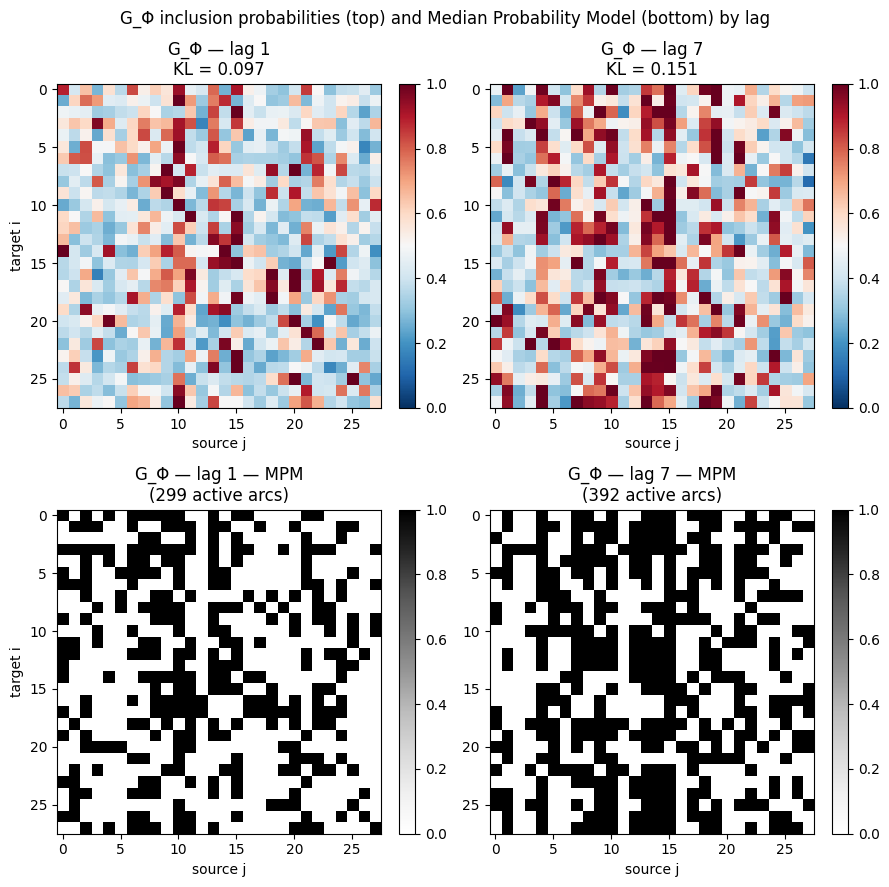

  Lag  Live arcs  Degenerate arcs Median ESS Frac < 100 Mean KL  MPM arcs
lag 1        763               21         46      99.3%  0.0975       299
lag 7        744               40         45      96.6%  0.1506       392


In [21]:
if "G_Phi" in samples:
    G_Phi = samples["G_Phi"]                          # (ny, ny, p, N)
    ny, _, p, N = G_Phi.shape

    # Inclusion probabilities and KL per lag
    edge_prob_GPhi = G_Phi.mean(axis=3)               # (ny, ny, p)

    # Two-row layout: top = inclusion probabilities, bottom = MPM (matches G_0 style)
    fig, axes = plt.subplots(2, p, figsize=(4.5 * p, 9))
    if p == 1:
        # When p == 1 subplots returns a 1-D array; reshape to 2-D for uniform indexing
        axes = axes.reshape(2, 1)

    kl_table = []
    for s in range(p):
        # ----- Top row: posterior inclusion probabilities -----
        ax_top = axes[0, s]
        e = edge_prob_GPhi[:, :, s]
        im_top = ax_top.imshow(e, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
        kl = float(np.mean(kl_bernoulli_to_uniform(e)))
        kl_table.append({"Lag": LAG_LABELS.get(s, f"lag {s+1}"),
                         "Mean KL(post||0.5)": f"{kl:.4f}",
                         "MPM active arcs": int((e > 0.5).sum())})
        ax_top.set_title(f"G_Φ — {LAG_LABELS.get(s, f'lag {s+1}')}\n"
                         f"KL = {kl:.3f}")
        ax_top.set_xlabel("source j")
        if s == 0:
            ax_top.set_ylabel("target i")
        plt.colorbar(im_top, ax=ax_top, fraction=0.046)

        # ----- Bottom row: Median Probability Model (MPM) -----
        ax_bot = axes[1, s]
        GPhi_mpm = (e > 0.5).astype(np.float32)
        n_mpm = int(np.nansum(GPhi_mpm))
        im_bot = ax_bot.imshow(GPhi_mpm, cmap="Greys", vmin=0, vmax=1, aspect="auto")
        ax_bot.set_title(f"G_Φ — {LAG_LABELS.get(s, f'lag {s+1}')} — MPM\n"
                         f"({n_mpm} active arcs)")
        ax_bot.set_xlabel("source j")
        if s == 0:
            ax_bot.set_ylabel("target i")
        plt.colorbar(im_bot, ax=ax_bot, fraction=0.046)

    fig.suptitle("G_Φ inclusion probabilities (top) and Median Probability Model (bottom) by lag",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

    # Per-lag ESS summary, excluding degenerate arcs
    rows = []
    for s in range(p):
        slab = G_Phi[:, :, s, :].astype(np.float64)
        # Compute ESS arc by arc — vectorized via reshape
        flat = slab.reshape(-1, N)
        var = flat.var(axis=1)
        live_mask = var > 0
        ess_live = np.array([ess_geyer(flat[k]) for k in np.where(live_mask)[0]])
        rows.append({
            "Lag":             LAG_LABELS.get(s, f"lag {s+1}"),
            "Live arcs":       int(live_mask.sum()),
            "Degenerate arcs": int((~live_mask).sum()),
            "Median ESS":      f"{np.median(ess_live):.0f}",
            "Frac < 100":      f"{(ess_live < 100).mean():.1%}",
            "Mean KL":         kl_table[s]["Mean KL(post||0.5)"],
            "MPM arcs":        kl_table[s]["MPM active arcs"],
        })
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print("G_Phi not in samples.")

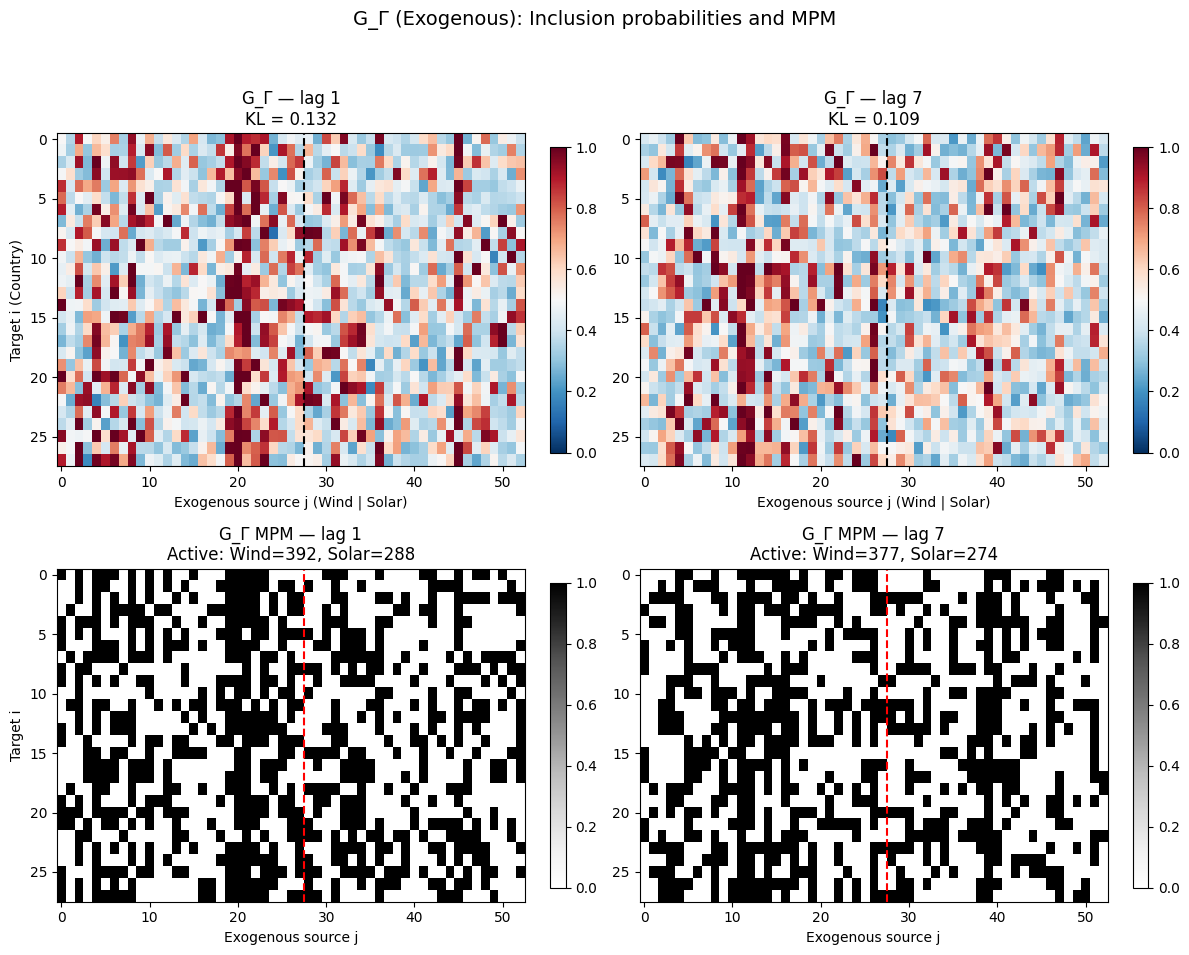


--- G_Gamma Efficiency and Selection Summary ---
  Lag  Live arcs  Wind MPM  Solar MPM Median ESS ESS < 100 Mean KL
lag 1       1419       392        288         45     98.2%  0.1323
lag 7       1452       377        274         46     98.7%  0.1086


In [22]:
if "G_Gamma" in samples:
    G_Gamma = samples["G_Gamma"]                          # (ny, nx, p, N)
    ny, nx, p, N = G_Gamma.shape
    n_wind = 28 # Come specificato prima
    
    # Probabilità di inclusione
    edge_prob_GGamma = G_Gamma.mean(axis=3)               # (ny, nx, p)

    # Layout: una riga per le Probabilità, una per l'MPM
    # Ogni colonna è un lag
    fig, axes = plt.subplots(2, p, figsize=(6 * p, 10))
    if p == 1:
        axes = axes.reshape(2, 1)

    kl_table = []
    for s in range(p):
        # ----- Top row: Posterior Inclusion Probabilities -----
        ax_top = axes[0, s]
        e = edge_prob_GGamma[:, :, s]
        
        im_top = ax_top.imshow(e, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
        
        # Linea verticale per separare Wind da Solar
        ax_top.axvline(x=n_wind - 0.5, color='black', linestyle='--', lw=1.5)
        
        kl = float(np.mean(kl_bernoulli_to_uniform(e)))
        kl_table.append({
            "Lag": LAG_LABELS.get(s, f"lag {s+1}"),
            "Mean KL": f"{kl:.4f}",
            "MPM Wind": int((e[:, :n_wind] > 0.5).sum()),
            "MPM Solar": int((e[:, n_wind:] > 0.5).sum())
        })
        
        ax_top.set_title(f"G_Γ — {LAG_LABELS.get(s, f'lag {s+1}')}\nKL = {kl:.3f}")
        ax_top.set_xlabel("Exogenous source j (Wind | Solar)")
        if s == 0: ax_top.set_ylabel("Target i (Country)")
        plt.colorbar(im_top, ax=ax_top, fraction=0.03)

        # ----- Bottom row: Median Probability Model (MPM) -----
        ax_bot = axes[1, s]
        GGamma_mpm = (e > 0.5).astype(np.float32)
        
        im_bot = ax_bot.imshow(GGamma_mpm, cmap="Greys", vmin=0, vmax=1, aspect="auto")
        ax_bot.axvline(x=n_wind - 0.5, color='red', linestyle='--', lw=1.5) # Separatore visivo
        
        n_wind_act = kl_table[s]["MPM Wind"]
        n_solar_act = kl_table[s]["MPM Solar"]
        
        ax_bot.set_title(f"G_Γ MPM — {LAG_LABELS.get(s, f'lag {s+1}')}\n"
                         f"Active: Wind={n_wind_act}, Solar={n_solar_act}")
        ax_bot.set_xlabel("Exogenous source j")
        if s == 0: ax_bot.set_ylabel("Target i")
        plt.colorbar(im_bot, ax=ax_bot, fraction=0.03)

    fig.suptitle("G_Γ (Exogenous): Inclusion probabilities and MPM", fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Summary Table con dettaglio Wind/Solar
    rows = []
    for s in range(p):
        slab = G_Gamma[:, :, s, :].astype(np.float64)
        flat = slab.reshape(-1, N)
        var = flat.var(axis=1)
        live_mask = var > 0
        
        # Calcolo ESS solo per archi non degeneri
        if live_mask.any():
            ess_live = np.array([ess_geyer(flat[k]) for k in np.where(live_mask)[0]])
            med_ess = f"{np.median(ess_live):.0f}"
            frac_low = f"{(ess_live < 100).mean():.1%}"
        else:
            med_ess, frac_low = "N/A", "0%"

        rows.append({
            "Lag":          LAG_LABELS.get(s, f"lag {s+1}"),
            "Live arcs":    int(live_mask.sum()),
            "Wind MPM":     kl_table[s]["MPM Wind"],
            "Solar MPM":    kl_table[s]["MPM Solar"],
            "Median ESS":   med_ess,
            "ESS < 100":    frac_low,
            "Mean KL":      kl_table[s]["Mean KL"]
        })
    
    import pandas as pd
    print("\n--- G_Gamma Efficiency and Selection Summary ---")
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print("G_Gamma not in samples.")

## Block diagnostics of $Σ_u$

logdet(Σ_u): median = +351.42, IQR = 3.21, max = +359.73


C:\Users\silvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\silvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


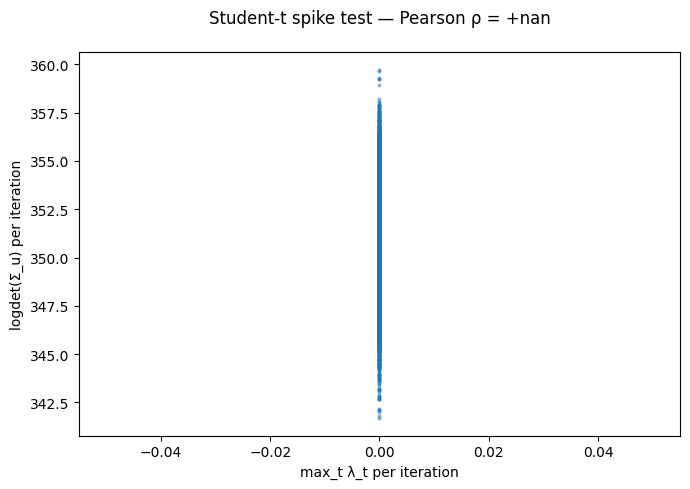

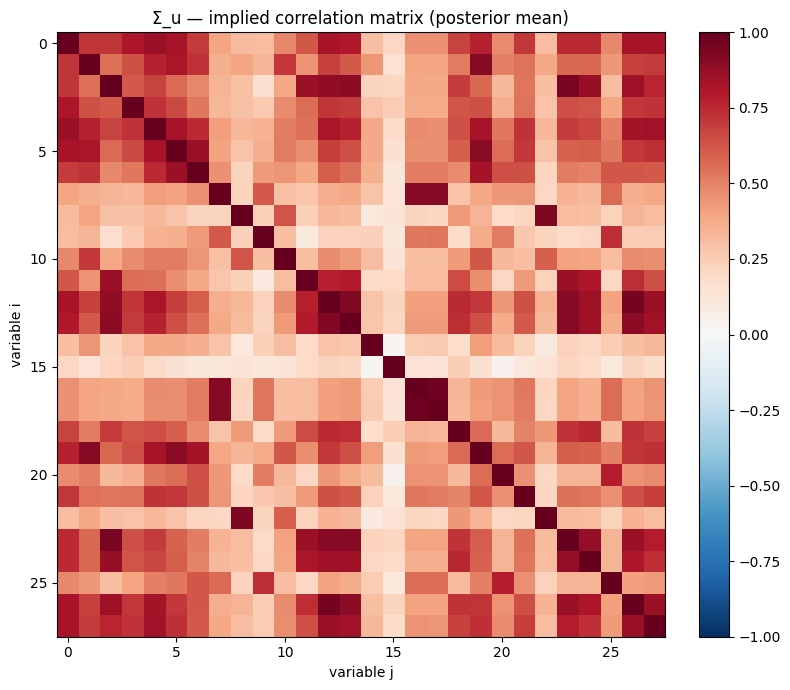

In [23]:
if "Sigma_u" in samples and "logdet_Sigma" in samples:
    Sig = samples["Sigma_u"]
    logdet = samples["logdet_Sigma"]
    ny, _, N = Sig.shape

    # --- Robust summary
    print(f"logdet(Σ_u): median = {np.median(logdet):+.2f}, "
          f"IQR = {np.percentile(logdet, 75) - np.percentile(logdet, 25):.2f}, "
          f"max = {logdet.max():+.2f}")

    # --- Spike interpretation test
    if "max_lambda_t" in scalars:
        max_lam = scalars["max_lambda_t"]
        rho = float(np.corrcoef(logdet, max_lam)[0, 1])
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(max_lam, logdet, s=4, alpha=0.4)
        ax.set_xlabel("max_t λ_t per iteration")
        ax.set_ylabel("logdet(Σ_u) per iteration")
        ax.set_title(f"Student-t spike test — Pearson ρ = {rho:+.2f}\n")
        fig.tight_layout()
        plt.show()

    # --- Posterior mean correlation matrix
    Sig_mean = Sig.mean(axis=2)
    d = np.sqrt(np.diag(Sig_mean))
    R = Sig_mean / np.outer(d, d)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_title("Σ_u — implied correlation matrix (posterior mean)")
    ax.set_xlabel("variable j")
    ax.set_ylabel("variable i")
    plt.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    plt.show()
else:
    print("Sigma_u or logdet_Sigma not in samples.")

## Block diagnostics of $Φ$

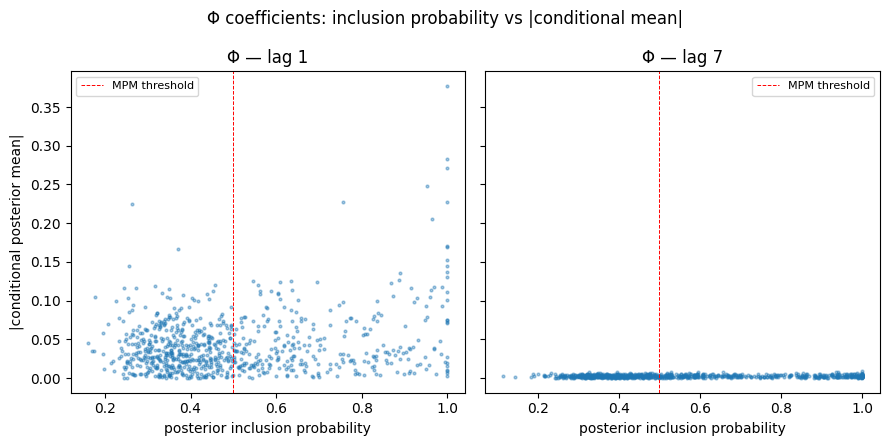

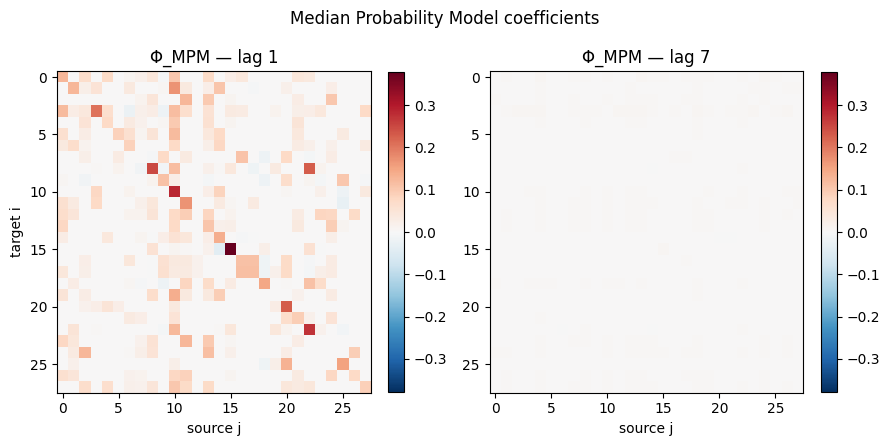

In [24]:
if "Phi" in samples and "G_Phi" in samples:
    Phi   = samples["Phi"]                            # (ny, ny, p, N)
    G_Phi = samples["G_Phi"]                          # (ny, ny, p, N)
    ny, _, p, N = Phi.shape

    incl_prob = G_Phi.mean(axis=3)                    # (ny, ny, p)

    # Conditional means: average Phi only over draws where G_Phi == 1
    cond_mean = np.full((ny, ny, p), np.nan)
    n_active = G_Phi.sum(axis=3)                      # (ny, ny, p)
    for s in range(p):
        for i in range(ny):
            for j in range(ny):
                if n_active[i, j, s] > 0:
                    mask = G_Phi[i, j, s, :] == 1
                    cond_mean[i, j, s] = Phi[i, j, s, mask].mean()

    # Scatter inclusion-vs-magnitude with MPM threshold line
    fig, axes = plt.subplots(1, p, figsize=(4.5 * p, 4.5), sharey=True)
    if p == 1:
        axes = [axes]
    for s in range(p):
        ax = axes[s]
        x = incl_prob[:, :, s].ravel()
        y = np.abs(cond_mean[:, :, s].ravel())
        ax.scatter(x, y, s=4, alpha=0.4)
        ax.axvline(0.5, color="red", ls="--", lw=0.7, label="MPM threshold")
        ax.set_xlabel("posterior inclusion probability")
        if s == 0:
            ax.set_ylabel("|conditional posterior mean|")
        ax.set_title(f"Φ — {LAG_LABELS.get(s, f'lag {s+1}')}")
        ax.legend(fontsize=8)
    fig.suptitle("Φ coefficients: inclusion probability vs |conditional mean|",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

    # Median Probability Model: keep only coefficients with incl > 0.5
    Phi_mpm = np.where(incl_prob > 0.5, cond_mean, 0.0)
    fig, axes = plt.subplots(1, p, figsize=(4.5 * p, 4.5))
    if p == 1:
        axes = [axes]
    vmax = max(0.01, float(np.nanmax(np.abs(Phi_mpm))))
    for s in range(p):
        ax = axes[s]
        im = ax.imshow(Phi_mpm[:, :, s], cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(f"Φ_MPM — {LAG_LABELS.get(s, f'lag {s+1}')}")
        ax.set_xlabel("source j")
        if s == 0:
            ax.set_ylabel("target i")
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle("Median Probability Model coefficients", fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    print("Phi or G_Phi not in samples.")

## Block diagnostics of the Stochastic Volatility

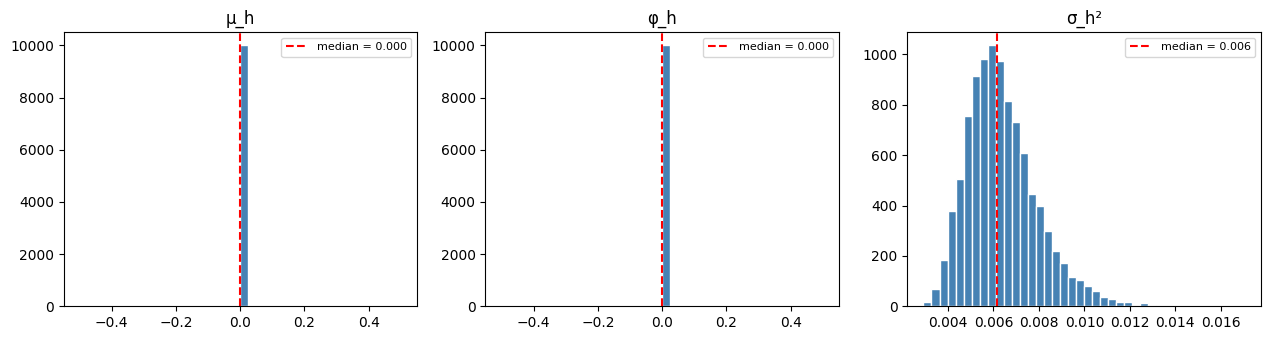

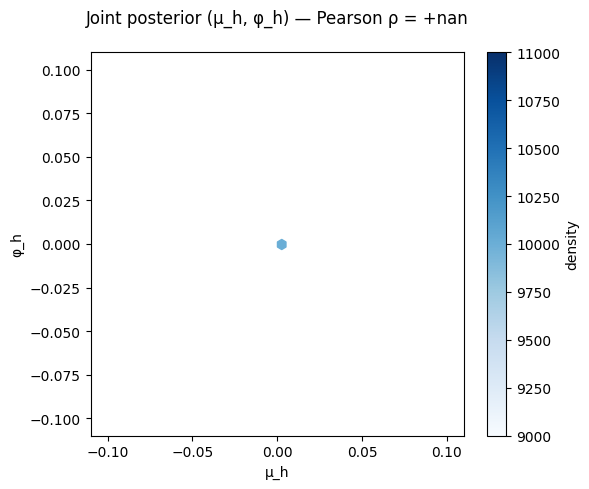

φ_h median = 0.000 — half-life undefined


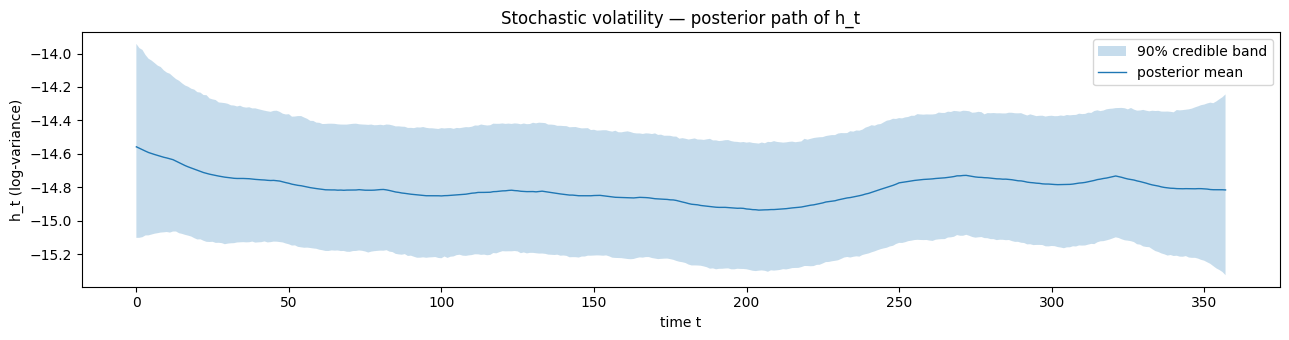

In [25]:
if all(k in samples for k in ("mu_h", "phi_h", "sigma_h2", "h", "lambda_t")):
    mu_h     = samples["mu_h"]
    phi_h    = samples["phi_h"]
    sigma_h2 = samples["sigma_h2"]
    h        = samples["h"]
    lam      = samples["lambda_t"]

    # --- Univariate posteriors
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for ax, x, title in zip(axes,
                             (mu_h, phi_h, sigma_h2),
                             ("μ_h", "φ_h", "σ_h²")):
        ax.hist(x, bins=40, color="steelblue", edgecolor="white")
        ax.axvline(np.median(x), color="red", ls="--",
                   label=f"median = {np.median(x):.3f}")
        ax.set_title(title)
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    # --- Joint (mu_h, phi_h) — the diagnostic for centered-parameterization issues
    rho_mp = float(np.corrcoef(mu_h, phi_h)[0, 1])
    fig, ax = plt.subplots(figsize=(6, 5))
    hb = ax.hexbin(mu_h, phi_h, gridsize=40, cmap="Blues", mincnt=1)
    ax.set_xlabel("μ_h")
    ax.set_ylabel("φ_h")
    ax.set_title(f"Joint posterior (μ_h, φ_h) — Pearson ρ = {rho_mp:+.2f}\n")
    plt.colorbar(hb, ax=ax, label="density")
    fig.tight_layout()
    plt.show()

    # --- Half-life of volatility shocks
    phi_med = np.median(phi_h)
    if 0 < phi_med < 1:
        half_life = float(np.log(0.5) / np.log(phi_med))
        print(f"Volatility-shock half-life: {half_life:.1f} periods "
              f"(at posterior median φ_h = {phi_med:.3f})")
    else:
        print(f"φ_h median = {phi_med:.3f} — half-life undefined")

    # --- h_t posterior path with credible band
    h_mean = h.mean(axis=1)
    h_lo   = np.percentile(h, 5, axis=1)
    h_hi   = np.percentile(h, 95, axis=1)
    fig, ax = plt.subplots(figsize=(13, 3.5))
    ax.fill_between(np.arange(h.shape[0]), h_lo, h_hi, alpha=0.25,
                    label="90% credible band")
    ax.plot(h_mean, lw=1.0, label="posterior mean")
    ax.set_xlabel("time t")
    ax.set_ylabel("h_t (log-variance)")
    ax.set_title("Stochastic volatility — posterior path of h_t")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("SV samples incomplete.")

### VAR stability
A VAR is stationary iff the spectral radius of the companion matrix is strictly below 1 in every posterior draw.

In [26]:
if "spectral_radius" in scalars:
    sr = scalars["spectral_radius"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(sr, lw=0.4, color="steelblue")
    axes[0].axhline(1.0, color="red", ls="--", label="unit circle")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("max |eigenvalue|")
    axes[0].set_title(f"Spectral radius — mean = {sr.mean():.3f}, "
                      f"max = {sr.max():.3f}")
    axes[0].legend()

    axes[1].hist(sr, bins=40, color="steelblue", edgecolor="white")
    for q, ls in [(0.5, "-"), (0.9, "--"), (0.99, ":")]:
        v = float(np.quantile(sr, q))
        axes[1].axvline(v, color="red", ls=ls, lw=0.8,
                        label=f"q{int(100*q)} = {v:.3f}")
    axes[1].set_xlabel("max |eigenvalue|")
    axes[1].set_title("Spectral radius — distribution")
    axes[1].legend()
    fig.tight_layout()
    plt.show()

    n_violations = int((sr >= 1).sum())
    print(f"Iterations with spectral radius >= 1: {n_violations} / {sr.size}")
    print(f"99th percentile of spectral radius:  {np.quantile(sr, 0.99):.3f}")
else:
    print("Spectral radius was not computed (set compute_spectral=True in Cell 6).")

Spectral radius was not computed (set compute_spectral=True in Cell 6).
